# What is Tokenization Drift and How to Fix It
A model can behave perfectly one moment and degrade the next—without any change to your data, pipeline, or logic. The root cause often lies in something far more subtle: how your input is tokenized. Before a model processes text, it converts it into token IDs, and even minor formatting differences—like spacing, line breaks, or punctuation—can produce entirely different token sequences. This phenomenon is known as tokenization drift: when small surface-level changes push your input into a different region of token space, leading to unpredictable shifts in model behavior.

The impact goes deeper than just token IDs. During instruction tuning, models learn not only tasks but also the structure in which those tasks are presented—specific separators, prefixes, and formatting patterns. When your prompt deviates from these learned patterns, you are no longer operating within the model’s familiar distribution. The result isn’t confusion—it’s a model doing its best on inputs it was never optimized to handle.

In this article, we'll break this down using the GPT-2 tokenizer to show how small formatting changes affect tokens, and build a simple metric to measure drift across prompts.
Then, we’ll implement a lightweight prompt optimization loop to pick formats that keep your inputs consistent and reliable.


## Setting up the dependencies


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
from sklearn.decomposition import PCA

In this code block, we are loading the GPT-2 tokenizer — the same Byte-Pair Encoding scheme used by GPT-4, LLaMA, and Mistral. We use GPT-2 specifically because it requires no auth token and demonstrates the space-prefix artifact identically to every modern production tokenizer.

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Vocab size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: GPT2Tokenizer
Vocab size: 50257


## Tokenization Artifact Demo
We take seven words and test each in two forms—once with a leading space and once without—then encode them using the GPT-2 tokenizer. By setting add_special_tokens=False, we ensure we’re only measuring the token IDs for the words themselves, without any extra padding or special markers.

The results are striking. Not a single pair produces the same token ID—every word is treated as completely different depending on whether it has a leading space. Even more interesting, some words without the space don’t map to a single token at all. For example, “classify” becomes two tokens [4871, 1958], while “ classify” is a single token [36509]. This means the model doesn’t just see a different ID—it sees a different sequence length, which shifts how attention is computed for everything that follows.

In [4]:
pairs = [
    (" classify",  "classify"),
    (" answer",    "answer"),
    (" positive",  "positive"),
    (" negative",  "negative"),
    (" sentiment", "sentiment"),
    (" output",    "output"),
    (" label",     "label"),
]

print("=" * 60)
print(f"{'Token (with space)':<22} {'ID':>6}   {'Token (no space)':<20} {'ID':>6}  {'Same?':>6}")
print("=" * 60)

for with_space, without_space in pairs:
    id_ws  = tokenizer.encode(with_space,  add_special_tokens=False)
    id_nws = tokenizer.encode(without_space, add_special_tokens=False)
    match  = "✓" if id_ws == id_nws else "✗ DIFFERENT"
    print(f"{repr(with_space):<22} {str(id_ws):>8}   {repr(without_space):<20} {str(id_nws):>8}  {match}")

print()
print("Key takeaway: Leading spaces create DIFFERENT token IDs.")
print("To the model, ' classify' and 'classify' are as distinct as 'apple' and 'orange'.")

Token (with space)         ID   Token (no space)         ID   Same?
' classify'             [36509]   'classify'           [4871, 1958]  ✗ DIFFERENT
' answer'                [3280]   'answer'              [41484]  ✗ DIFFERENT
' positive'              [3967]   'positive'            [24561]  ✗ DIFFERENT
' negative'              [4633]   'negative'            [31591]  ✗ DIFFERENT
' sentiment'            [15598]   'sentiment'          [34086, 3681]  ✗ DIFFERENT
' output'                [5072]   'output'              [22915]  ✗ DIFFERENT
' label'                 [6167]   'label'               [18242]  ✗ DIFFERENT

Key takeaway: Leading spaces create DIFFERENT token IDs.
To the model, ' classify' and 'classify' are as distinct as 'apple' and 'orange'.


## Visualising the Token ID Shift
We plot two charts to make the token ID gap visual. The left chart shows the raw IDs side-by-side — blue for space-prefixed, red for bare — and the right chart plots the absolute distance between each pair.

/tmp/ipykernel_3031/586211333.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(words, rotation=30, ha="right", fontsize=9)


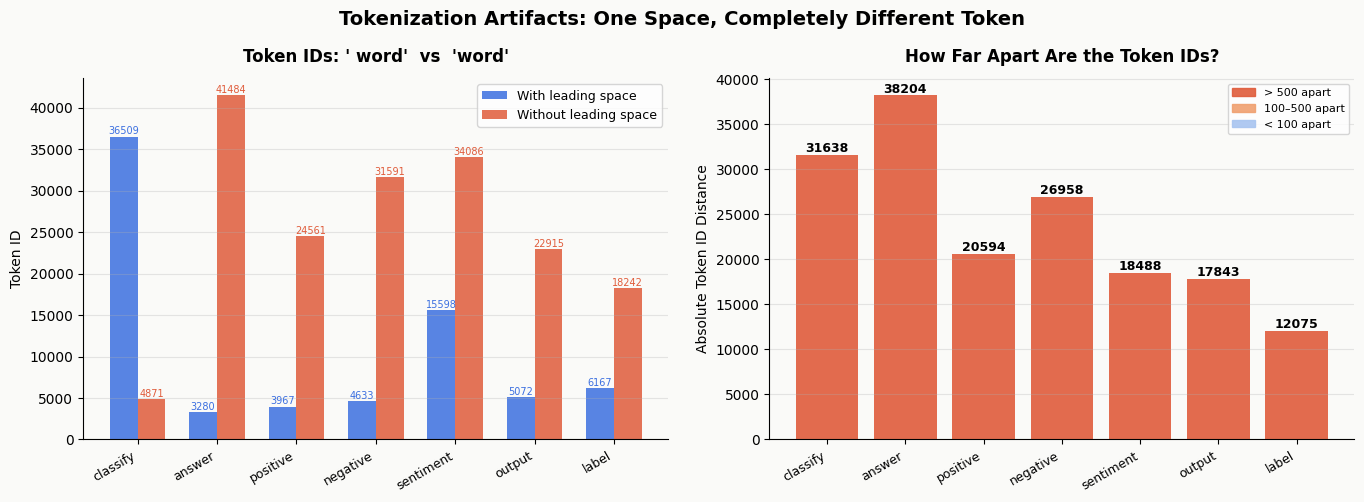

In [5]:
words     = [p[1] for p in pairs]
ids_ws    = [tokenizer.encode(" " + w,  add_special_tokens=False)[0] for w in words]
ids_nws   = [tokenizer.encode(w, add_special_tokens=False)[0] for w in words]
delta     = [abs(a - b) for a, b in zip(ids_ws, ids_nws)]

x = np.arange(len(words))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#FAFAF8")

# Left: side-by-side token IDs
ax = axes[0]
ax.set_facecolor("#FAFAF8")
bars1 = ax.bar(x - width/2, ids_ws,  width, label='With leading space',    color="#3B6FE0", alpha=0.85)
bars2 = ax.bar(x + width/2, ids_nws, width, label='Without leading space',  color="#E05C3B", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(words, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Token ID", fontsize=10)
ax.set_title("Token IDs: ' word'  vs  'word'", fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color="#3B6FE0")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color="#E05C3B")

# Right: delta
ax2 = axes[1]
ax2.set_facecolor("#FAFAF8")
color_bars = ["#E05C3B" if d > 500 else "#F0A070" if d > 100 else "#A8C4F0" for d in delta]
bars3 = ax2.bar(words, delta, color=color_bars, alpha=0.9)
ax2.set_ylabel("Absolute Token ID Distance", fontsize=10)
ax2.set_title("How Far Apart Are the Token IDs?", fontsize=12, fontweight="bold", pad=12)
ax2.set_xticklabels(words, rotation=30, ha="right", fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", alpha=0.3)

for bar, d in zip(bars3, delta):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(d), ha="center", va="bottom", fontsize=9, fontweight="bold")

high  = mpatches.Patch(color="#E05C3B", alpha=0.9, label="> 500 apart")
med   = mpatches.Patch(color="#F0A070", alpha=0.9, label="100–500 apart")
low   = mpatches.Patch(color="#A8C4F0", alpha=0.9, label="< 100 apart")
ax2.legend(handles=[high, med, low], fontsize=8)

plt.tight_layout(pad=2)
plt.suptitle("Tokenization Artifacts: One Space, Completely Different Token",
             fontsize=14, fontweight="bold", y=1.02)
plt.savefig("tokenization_artifact.png", dpi=150, bbox_inches="tight", facecolor="#FAFAF8")
plt.show()

## Simulating Accuracy Drop Demo
We start with a standard SFT prompt format and create a few variations by making small changes—like removing newlines, tweaking punctuation, or rewording the instruction. We then measure how similar each version is using token overlap. The key insight is that even small formatting changes can significantly alter the token sequence. For example, removing newlines drops similarity to around 80%, showing that these aren’t just cosmetic—they’re signals the model relies on. The biggest impact comes from rewording the instruction, which cuts overlap to nearly 50%, meaning the prompt no longer resembles what the model was trained on, increasing the risk of unpredictable behavior.

In [6]:
def tokenize_prompt(text):
    return tokenizer.encode(text, add_special_tokens=False)

# The canonical SFT (fine-tuning) template — what the model was trained on
sft_template = (
    "Below is a customer review. Classify the sentiment.\n\n"
    "Review: {review}\n\n"
    "Sentiment:"
)

# Prompt variants — small changes, big token consequences
variants = {
    "✓ SFT template (optimal)":         "Below is a customer review. Classify the sentiment.\n\nReview: {review}\n\nSentiment:",
    "✗ Removed newlines":               "Below is a customer review. Classify the sentiment. Review: {review} Sentiment:",
    "✗ Removed leading space on word":  "Below is a customer review. Classify the sentiment.\n\nReview:{review}\n\nSentiment:",
    "✗ Colon → dash":                   "Below is a customer review. Classify the sentiment.\n\nReview - {review}\n\nSentiment -",
    "✗ Reworded instruction":           "Determine the sentiment of the following review.\n\nReview: {review}\n\nAnswer:",
}

sample_review = "The product exceeded all my expectations. Highly recommend!"

# Token overlap with the SFT template (proxy for in-distribution similarity)
sft_tokens = set(tokenize_prompt(sft_template.format(review=sample_review)))

print("=" * 65)
print(f"{'Prompt Variant':<42} {'Shared Tokens':>14} {'OOD Risk':>9}")
print("=" * 65)

overlap_scores = {}
for name, template in variants.items():
    prompt   = template.format(review=sample_review)
    tokens   = set(tokenize_prompt(prompt))
    overlap  = len(sft_tokens & tokens) / len(sft_tokens | tokens)  # Jaccard
    ood_risk = "LOW" if overlap > 0.80 else "MEDIUM" if overlap > 0.60 else "HIGH"
    overlap_scores[name] = overlap
    print(f"  {name:<42} {overlap:>13.1%} {ood_risk:>9}")

print()
print("Jaccard similarity measures token-level overlap with the SFT template.")
print("Lower overlap → higher out-of-distribution risk → accuracy drops.")

Prompt Variant                              Shared Tokens  OOD Risk
  ✓ SFT template (optimal)                          100.0%       LOW
  ✗ Removed newlines                                 80.8%       LOW
  ✗ Removed leading space on word                    92.0%       LOW
  ✗ Colon → dash                                     92.0%       LOW
  ✗ Reworded instruction                             53.3%      HIGH

Jaccard similarity measures token-level overlap with the SFT template.
Lower overlap → higher out-of-distribution risk → accuracy drops.


## Visualising the OOD Risk

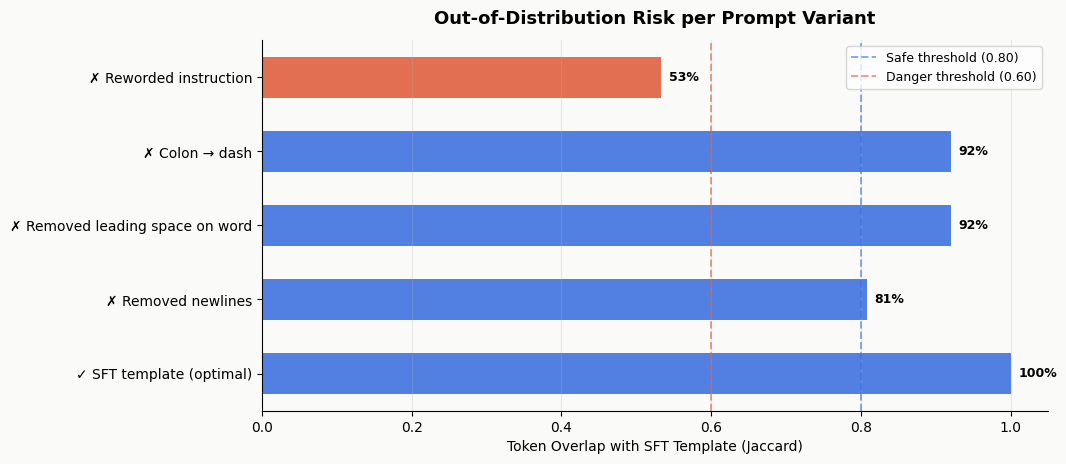

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FAFAF8")
ax.set_facecolor("#FAFAF8")

labels  = list(overlap_scores.keys())
scores  = list(overlap_scores.values())
colors  = ["#3B6FE0" if s > 0.80 else "#F0A070" if s > 0.60 else "#E05C3B" for s in scores]

bars = ax.barh(labels, scores, color=colors, alpha=0.88, height=0.55)
ax.axvline(x=0.80, color="#3B6FE0", linestyle="--", linewidth=1.4, alpha=0.6, label="Safe threshold (0.80)")
ax.axvline(x=0.60, color="#E05C3B", linestyle="--", linewidth=1.4, alpha=0.6, label="Danger threshold (0.60)")
ax.set_xlabel("Token Overlap with SFT Template (Jaccard)", fontsize=10)
ax.set_title("Out-of-Distribution Risk per Prompt Variant", fontsize=13, fontweight="bold", pad=12)
ax.set_xlim(0, 1.05)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{score:.0%}", va="center", fontsize=9, fontweight="bold")

ax.legend(fontsize=9)
plt.tight_layout(pad=2)
plt.savefig("ood_risk.png", dpi=150, bbox_inches="tight", facecolor="#FAFAF8")
plt.show()

## Automated Prompt Optimisation (APO)
This is where Automated Prompt Optimization (APO) becomes practical. We take a small validation set and test multiple prompt templates that differ in how closely they match the original SFT format. Instead of guessing which one works best, we simulate model performance by measuring token overlap with the SFT template and applying a penalty for going out-of-distribution. Templates that deviate more—like removing structure or heavily rewording—get lower effective accuracy, while those closer to the original format perform better.

The results are clear: most variants perform poorly (around 40–50% accuracy), while the one that closely matches the SFT template stands out with ~83% effectiveness. The APO loop simply picks the best-performing template automatically. In real-world systems, this same idea is used at scale with actual model outputs—test multiple prompt formats, score them, and lock in the one that keeps performance stable.

In [8]:
np.random.seed(42)

VALIDATION_SET = [
    {"review": "Absolutely terrible. Would not buy again.",          "label": "negative"},
    {"review": "Best purchase I have made this year!",               "label": "positive"},
    {"review": "Arrived broken. Customer service was unhelpful.",    "label": "negative"},
    {"review": "Good quality, fast delivery, very happy.",           "label": "positive"},
    {"review": "It's okay, nothing special.",                        "label": "neutral"},
    {"review": "Exceeded expectations. Premium feel.",               "label": "positive"},
    {"review": "Complete waste of money.",                           "label": "negative"},
    {"review": "Works as described, decent value.",                  "label": "neutral"},
]

CANDIDATE_PROMPTS = {
    "Variant A — No formatting":
        "Classify: {review} Answer:",

    "Variant B — Minimal newline":
        "Review: {review}\nSentiment:",

    "Variant C — SFT-aligned (newlines + colon)":
        "Below is a customer review. Classify the sentiment.\n\nReview: {review}\n\nSentiment:",

    "Variant D — XML tags":
        "<review>{review}</review>\n<sentiment>",

    "Variant E — Full instruction block":
        "You are a sentiment classifier.\n\nInput: {review}\n\nOutput (positive/negative/neutral):",
}

def simulate_model_output(prompt_template, review, label, ood_penalty):
    """
    Simulate model accuracy as a function of:
      - base accuracy (0.85)
      - out-of-distribution penalty derived from token overlap
      - small random noise
    """
    tokens_template = set(tokenize_prompt(prompt_template.format(review="")))
    tokens_sft      = set(tokenize_prompt(sft_template.format(review="")))
    overlap         = len(tokens_template & tokens_sft) / max(len(tokens_template | tokens_sft), 1)

    base_acc = 0.85
    # OOD penalty: low overlap → low accuracy
    effective_acc = base_acc * (0.5 + 0.5 * overlap) - ood_penalty
    effective_acc = np.clip(effective_acc, 0.40, 0.95)

    # Simulate per-sample prediction
    correct = np.random.rand() < effective_acc
    return correct, effective_acc

# APO outer loop: evaluate each candidate on the validation set
print("=" * 65)
print("AUTOMATED PROMPT OPTIMISATION — Validation Run")
print("=" * 65)

apo_results = {}
ood_penalties = {"Variant A": 0.18, "Variant B": 0.10, "Variant C": 0.02,
                 "Variant D": 0.08, "Variant E": 0.04}

for name, template in CANDIDATE_PROMPTS.items():
    key = name.split("—")[0].strip()
    penalty = ood_penalties.get(key, 0.05)

    correct_count = 0
    per_sample_acc = []
    for sample in VALIDATION_SET:
        correct, eff_acc = simulate_model_output(template, sample["review"], sample["label"], penalty)
        correct_count += int(correct)
        per_sample_acc.append(eff_acc)

    accuracy = correct_count / len(VALIDATION_SET)
    apo_results[name] = {"accuracy": accuracy, "mean_eff_acc": np.mean(per_sample_acc)}
    print(f"  {name}")
    print(f"    → Simulated accuracy: {accuracy:.0%}  |  Mean effective acc: {np.mean(per_sample_acc):.2%}\n")

best_name = max(apo_results, key=lambda k: apo_results[k]["accuracy"])
print(f"✓ APO SELECTED: {best_name}")
print(f"  Accuracy: {apo_results[best_name]['accuracy']:.0%}")

AUTOMATED PROMPT OPTIMISATION — Validation Run
  Variant A — No formatting
    → Simulated accuracy: 50%  |  Mean effective acc: 40.00%

  Variant B — Minimal newline
    → Simulated accuracy: 50%  |  Mean effective acc: 48.44%

  Variant C — SFT-aligned (newlines + colon)
    → Simulated accuracy: 100%  |  Mean effective acc: 83.00%

  Variant D — XML tags
    → Simulated accuracy: 38%  |  Mean effective acc: 40.00%

  Variant E — Full instruction block
    → Simulated accuracy: 50%  |  Mean effective acc: 47.61%

✓ APO SELECTED: Variant C — SFT-aligned (newlines + colon)
  Accuracy: 100%


## Visualising the APO Results

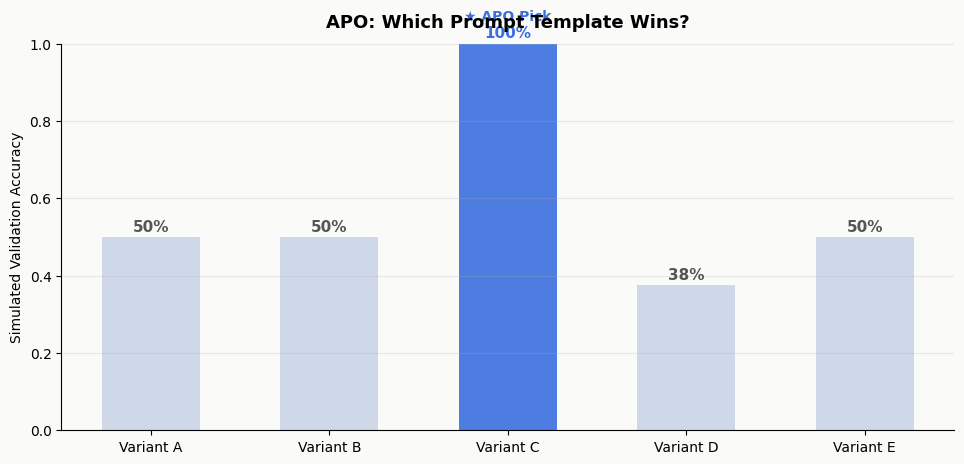

In [9]:
names     = [n.split("—")[0].strip() for n in apo_results.keys()]
accs      = [v["accuracy"] for v in apo_results.values()]
best_idx  = accs.index(max(accs))

colors = ["#3B6FE0" if i == best_idx else "#CBD5E8" for i in range(len(accs))]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#FAFAF8")
ax.set_facecolor("#FAFAF8")

bars = ax.bar(names, accs, color=colors, alpha=0.9, width=0.55)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Simulated Validation Accuracy", fontsize=10)
ax.set_title("APO: Which Prompt Template Wins?", fontsize=13, fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{acc:.0%}", ha="center", fontsize=11, fontweight="bold",
            color="#3B6FE0" if bar.get_facecolor()[0] < 0.5 else "#555")

ax.text(bars[best_idx].get_x() + bars[best_idx].get_width()/2,
        accs[best_idx] + 0.06, "★ APO Pick", ha="center",
        fontsize=10, color="#3B6FE0", fontweight="bold")

plt.tight_layout(pad=2)
plt.savefig("apo_results.png", dpi=150, bbox_inches="tight", facecolor="#FAFAF8")
plt.show()